# Gaussian q1

In [16]:
from sklearn import datasets as sk_datasets
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score, silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import permutations

In [17]:
n_samples = 500
seed = 30

noisy_circles = sk_datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=seed)
noisy_moons = sk_datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=seed)
blobs = sk_datasets.make_blobs(n_samples=n_samples, random_state=seed)
rng = np.random.RandomState(seed)
no_structure = rng.rand(n_samples, 2), np.zeros(n_samples)

random_state = 170
X, y = sk_datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

varied = sk_datasets.make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state)

datasets = [noisy_circles, noisy_moons, varied, aniso, blobs, no_structure]

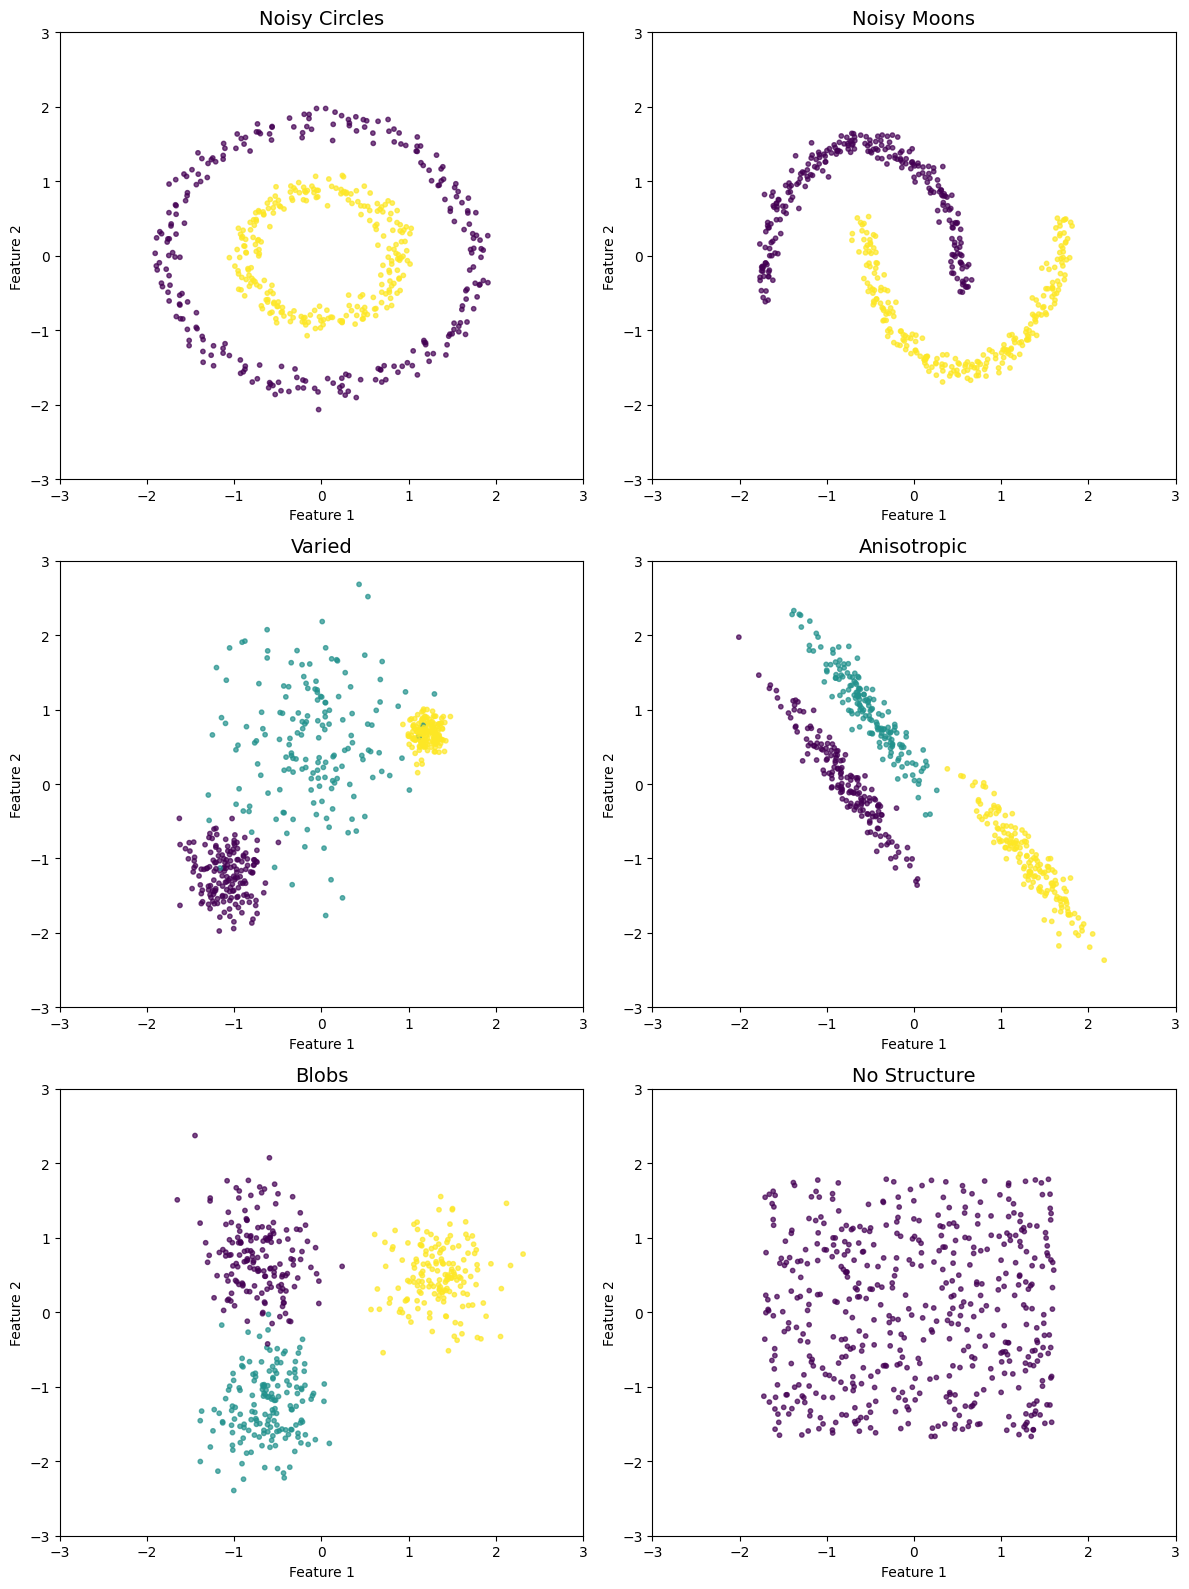

In [18]:
titles = ["Noisy Circles", "Noisy Moons", "Varied", "Anisotropic", "Blobs", "No Structure"]

fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.flatten()

for i, (data, title) in enumerate(zip(datasets, titles)):
    X, y = data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    colors = y if len(np.unique(y)) > 1 else np.zeros(len(y))
    axes[i].scatter(X_scaled[:, 0], X_scaled[:, 1], c=colors, cmap='viridis', s=10, alpha=0.7)
    axes[i].set_title(title, fontsize=14)
    axes[i].set_xlabel("Feature 1")
    axes[i].set_ylabel("Feature 2")
    axes[i].set_xlim(-3, 3)
    axes[i].set_ylim(-3, 3)

plt.tight_layout()
plt.show()

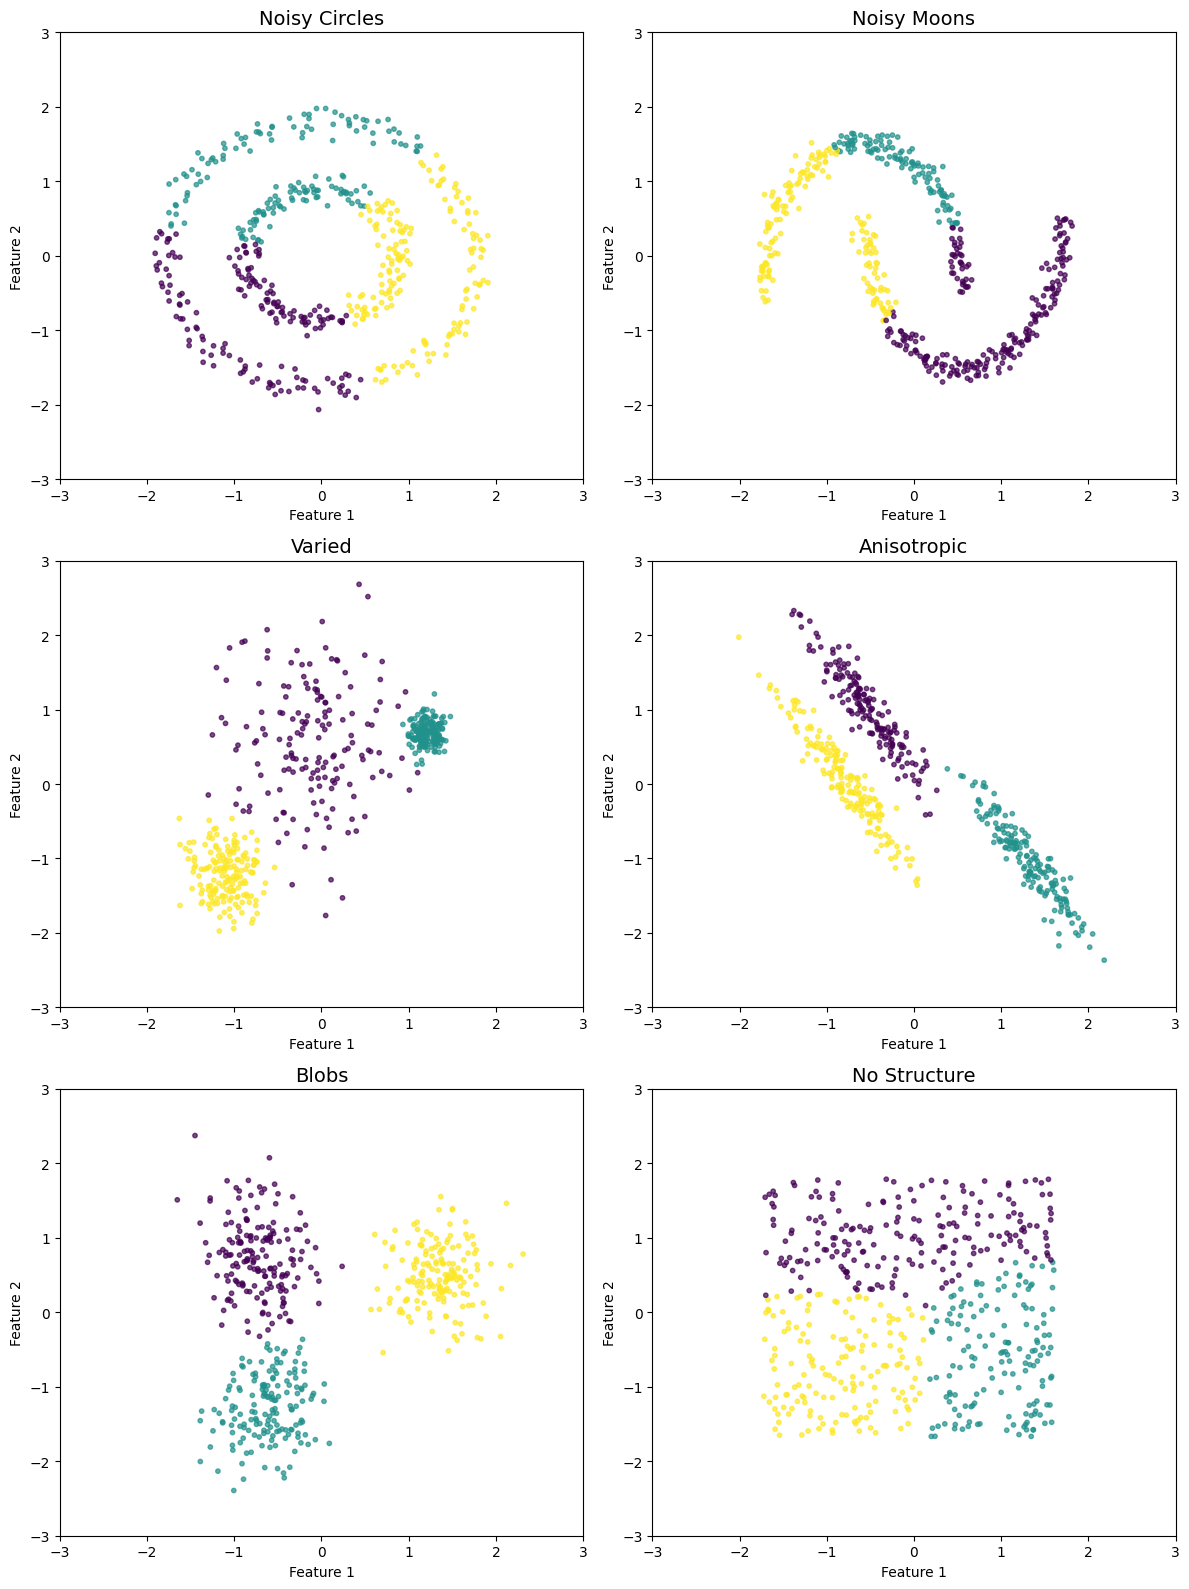

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.flatten()

for i, (data, title) in enumerate(zip(datasets, titles)):
    X, y = data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    y_pred = gmm.predict(X_scaled)
    axes[i].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred, cmap='viridis', s=10, alpha=0.7)
    axes[i].set_title(title, fontsize=14)
    axes[i].set_xlabel("Feature 1")
    axes[i].set_ylabel("Feature 2")
    axes[i].set_xlim(-3, 3)
    axes[i].set_ylim(-3, 3)

plt.tight_layout()
plt.show()

In [20]:
def clustering_accuracy(y_true, y_pred):
    unique_true = np.unique(y_true)
    unique_pred = np.unique(y_pred)
    n = len(y_true)
    best_acc = 0
    for perm in permutations(unique_pred, len(unique_true)):
        mapping = dict(zip(unique_true, perm))
        mapped = np.array([mapping.get(t, -1) for t in y_true])
        acc = np.sum(mapped == y_pred) / n
        if acc > best_acc:
            best_acc = acc
    return best_acc

results = []

for i, (data, title) in enumerate(zip(datasets, titles)):
    X, y = data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    y_pred = gmm.predict(X_scaled)

    sil = silhouette_score(X_scaled, y_pred)
    has_labels = len(np.unique(y)) > 1

    if has_labels:
        acc = clustering_accuracy(y.astype(int), y_pred)
        ari = adjusted_rand_score(y, y_pred)
        fms = fowlkes_mallows_score(y, y_pred)
    else:
        acc = "N/A"
        ari = "N/A"
        fms = "N/A"

    results.append({
        "Dataset": title,
        "Accuracy": acc,
        "Adjusted Rand Index": ari,
        "Fowlkes-Mallows": fms,
        "Silhouette": round(sil, 4)
    })

df_results = pd.DataFrame(results)
df_results

,Dataset,Accuracy,Adjusted Rand Index,Fowlkes-Mallows,Silhouette
0,Noisy Circles,0.346,-0.002469,0.405734,0.3871
1,Noisy Moons,0.602,0.298153,0.599292,0.4165
2,Varied,0.982,0.946819,0.964478,0.5881
3,Anisotropic,1.0,1.0,1.0,0.4587
4,Blobs,0.988,0.964437,0.976246,0.6538
5,No Structure,N/A,N/A,N/A,0.3788


### Task 4: GMM Performance Analysis

**Performed well:** Blobs, Anisotropic, and Varied — all have Gaussian-like (elliptical/spherical) cluster shapes, which match GMM's parametric assumption. Full-covariance GMM captures differences in spread, orientation, and size.

**Performed poorly:** Noisy Circles and Noisy Moons — both have non-convex cluster geometry (concentric rings, interleaving crescents) that cannot be represented by any mixture of Gaussian ellipsoids. No Structure has no real clusters, so GMM partitions are meaningless.

### Task 5: Per-Metric Interpretation

- **Accuracy:** Near-perfect for Anisotropic (1.0), Blobs (0.988), Varied (0.982). Poor for Noisy Circles (0.346) and Noisy Moons (0.602) due to non-convex geometry.
- **ARI:** Confirms the same pattern — Anisotropic (1.0), Blobs (0.964), Varied (0.947) show strong agreement; Noisy Circles (−0.002) is no better than random; Noisy Moons (0.298) is weak.
- **Fowlkes–Mallows:** Tracks ARI closely. High for Gaussian-shaped datasets (≥0.964), low for non-convex ones (0.406–0.599).
- **Silhouette:** Blobs highest (0.654) due to compact, well-separated clusters. Anisotropic is lower (0.459) despite perfect accuracy because elongated clusters increase intra-cluster distances. No Structure (0.379) confirms no meaningful clustering.